# 202 — GST design tutorial (fst_to_gst)

This short tutorial demonstrates converting a fixed-sample design (FSD) into a group-sequential (GST) design using the `fst_to_gst` helpers and shows a minimal example of creating a `BinomialABTest` ledger-backed test. The notebook is intentionally small and uses low `n_sim` values so it runs quickly in the project's test environment (poetry).

Prerequisites:
- This notebook is intended to run inside the project's Poetry environment (e.g. `poetry run jupyter lab` or `poetry run jupyter nbconvert --execute ...`).
- We use small simulation counts (`n_sim`) so CI and local iterations stay fast.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Imports: keep these minimal so the notebook runs fast
import ibis
import pprint
import matplotlib.pyplot as plt

from earlysign.stats.applications.design.group_sequential.initial_design.scenarios.fst_to_gst import (
    add_interim,
    add_interim_keep_power,
)
from earlysign.stats.essentials.methods.group_sequential.spending import PocockSpending
from earlysign.api.ab_tests import BinomialABTest

pp = pprint.PrettyPrinter(indent=2)

Compute a small GST design by converting an FSD to GST timings and then simulating operating characteristics.
The calls below intentionally use small `n_sim` so they run quickly in CI / local iterative runs.

In [3]:
# Design parameters (small, demo-friendly)
alpha = 0.05
delta = 0.02  # detectable difference (absolute proportion)
power = 0.8
ks = [2, 3]  # number of analyses to try (kept small for demo/CI)
p_control = 0.10
allocation_ratio = 1.0
n_sim = 200  # very small Monte-Carlo count for a quick demo
batch_size = 100
seed = 123

# Use a classic Pocock spending for the demo (pass string key)
spending = "pocock"

# Import the class-based API and helpers
from earlysign.stats.applications.design.group_sequential.initial_design.scenarios.fst_to_gst import (
    AddInterimToFixedSampleTest,
    _build_two_prop_procedure_factory,
    _spending_factory,
    _spending_family,
)
from earlysign.stats.essentials.schemes.two_proportions.asn import build_asn_calculator
import numpy as np

# Build spending object and factories (in the notebook for clarity)
spending_obj = _spending_factory(spending, alpha=alpha)


def asn_calculator_factory():
    return build_asn_calculator(
        alpha=alpha,
        beta=1.0 - power,
        sided=2,
        p_control=p_control,
        effect_size=delta,
        allocation_ratio=allocation_ratio,
        spending=spending_obj,
    )


procedure_factory = _build_two_prop_procedure_factory(
    spending_obj=spending_obj,
    alpha=alpha,
    allocation_ratio=allocation_ratio,
)


# Instantiate the class-based helper and run the quick demo
inst = AddInterimToFixedSampleTest(
    alpha=alpha,
    delta=delta,
    power=power,
    p_control=p_control,
    allocation_ratio=allocation_ratio,
    procedure_factory=procedure_factory,
    asn_calculator_factory=asn_calculator_factory,
    # For the quick demo keep a small grid of effect sizes (fast)
    effect_sizes=np.arange(0.01, 0.05, 0.002).tolist(),  # 0.01 .. 0.04 step 0.01
    n_sim=n_sim,
    batch_size=batch_size,
    seed=seed,
)

inst.design_fst()

{'n_fsd_per_group': 3839, 'planned_max_n': 7678}

=== k=2 ===
planned_max_n: 7678
n_per_analysis: 1920
power_at_delta: 0.835
sample_sizes: [3750, 7678]
n_fsd_per_group (if present): 3839
fsd_total (if present): 7678
=== k=3 ===
planned_max_n: 7678
n_per_analysis: 1280
power_at_delta: 0.855
sample_sizes: [2817, 4721, 7678]
n_fsd_per_group (if present): 3839
fsd_total (if present): 7678


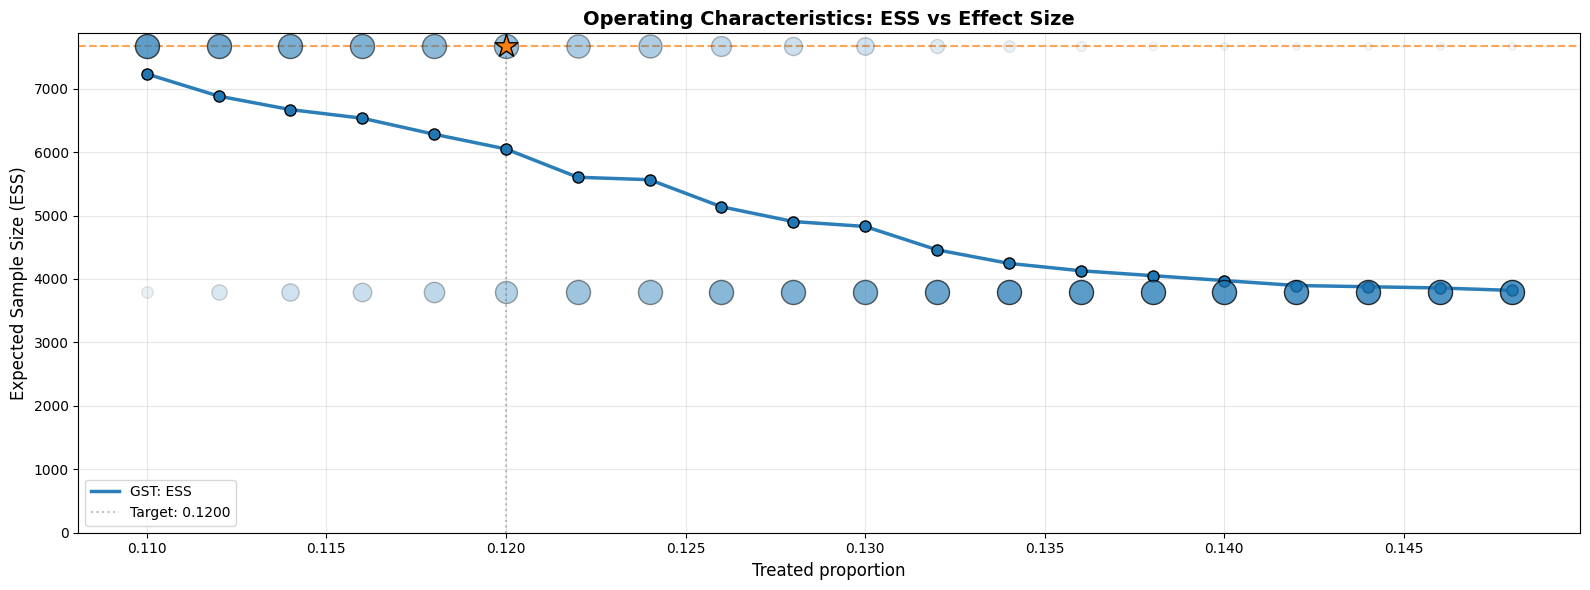

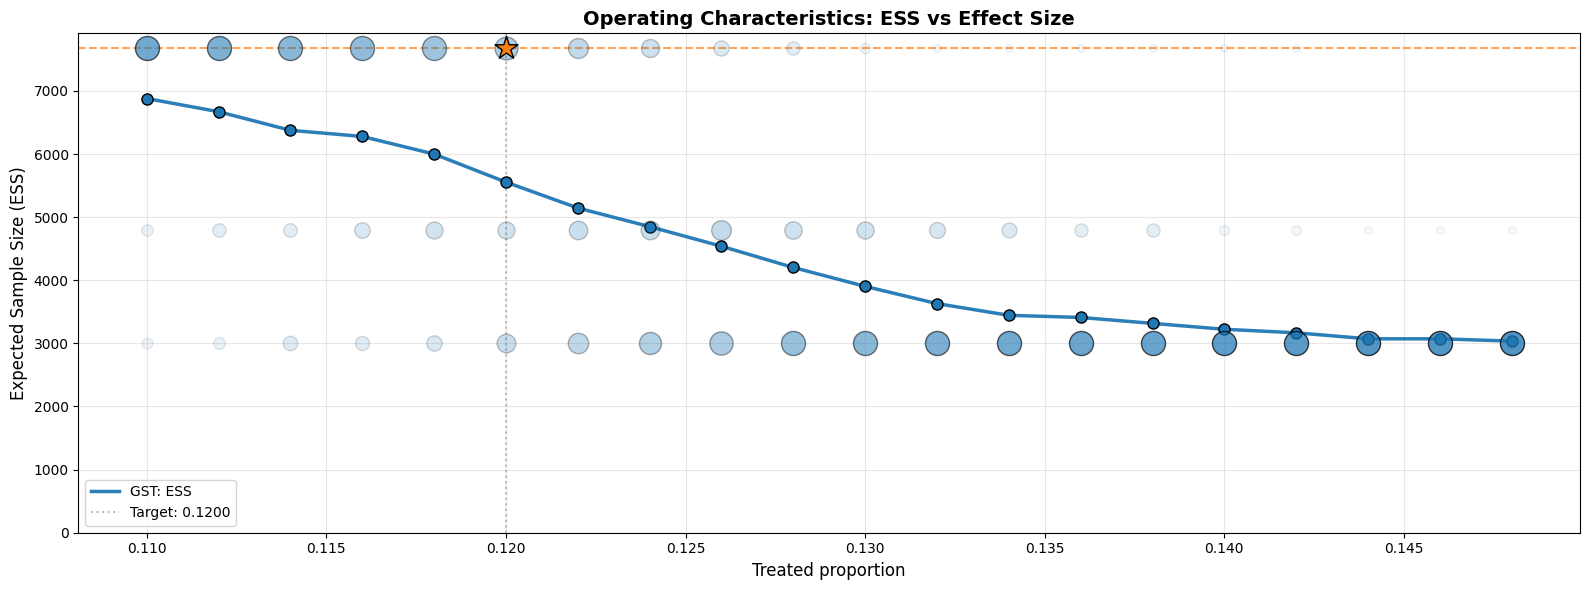

In [4]:
results = {}
for k in ks:
    # Pass plot_options so the plot enforces the requested bottom (e.g. 0)
    results[k] = inst.compare_interim(
        k=k, keep_power_at_H1=False, plot_options={"y_bottom": 0}
    )

# # Summarize results
# for k, meta in results.items():
#     print(f"=== k={k} analyses ===")
#     if isinstance(meta, dict):
#         print("Keys available:", sorted(list(meta.keys())))
#         print("power_at_delta:", meta.get("power_at_delta"))
#     else:
#         print("Result for k=", k, " ->", repr(meta))

# k ごとのメタ情報を詳しく表示するデバッグ用コード
for k, meta in results.items():
    print(f"=== k={k} ===")
    if isinstance(meta, dict):
        print("planned_max_n:", meta.get("planned_max_n"))
        print("n_per_analysis:", meta.get("n_per_analysis"))
        print("power_at_delta:", meta.get("power_at_delta"))
        # oc_results の中からターゲット効果(delta)に最も近い点の metadata を調べる
        oc = meta.get("oc_results", [])
        if oc:
            # oc は OCPointResult のリスト想定。metadata に sample_sizes が入っているはず
            closest = min(oc, key=lambda r: abs(r.effect_size - float(delta)))
            md = getattr(closest, "metadata", {}) or {}
            print("sample_sizes:", md.get("sample_sizes"))
            print("n_fsd_per_group (if present):", md.get("n_fsd_per_group"))
            print("fsd_total (if present):", md.get("fsd_total"))
    else:
        print("Result is not a dict:", repr(meta))

=== k=2 analyses ===
Keys available: ['boundaries', 'design_payload', 'info_times', 'n_per_analysis', 'oc_results', 'planned_max_n', 'plot_axes', 'plot_error', 'power_at_delta', 'procedure_metadata']
power_at_delta: 0.79
=== k=3 analyses ===
Keys available: ['boundaries', 'design_payload', 'info_times', 'n_per_analysis', 'oc_results', 'planned_max_n', 'plot_axes', 'plot_error', 'power_at_delta', 'procedure_metadata']
power_at_delta: 0.795


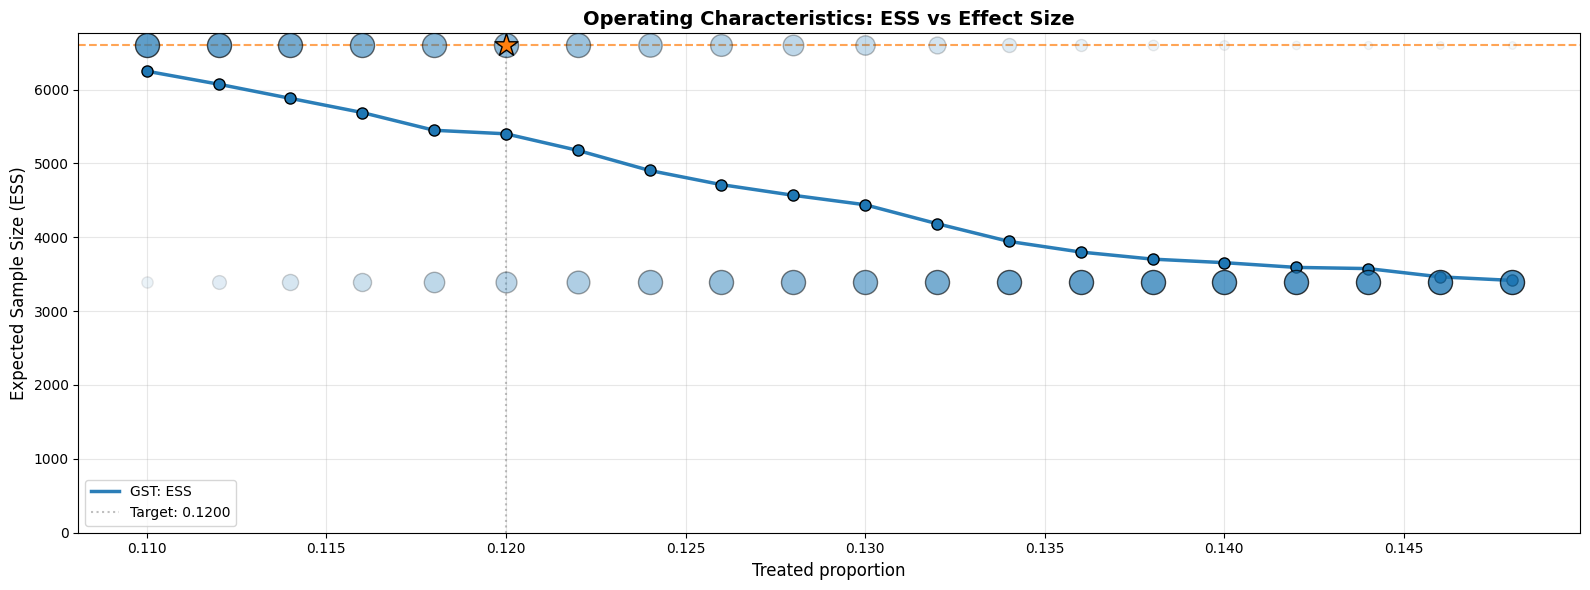

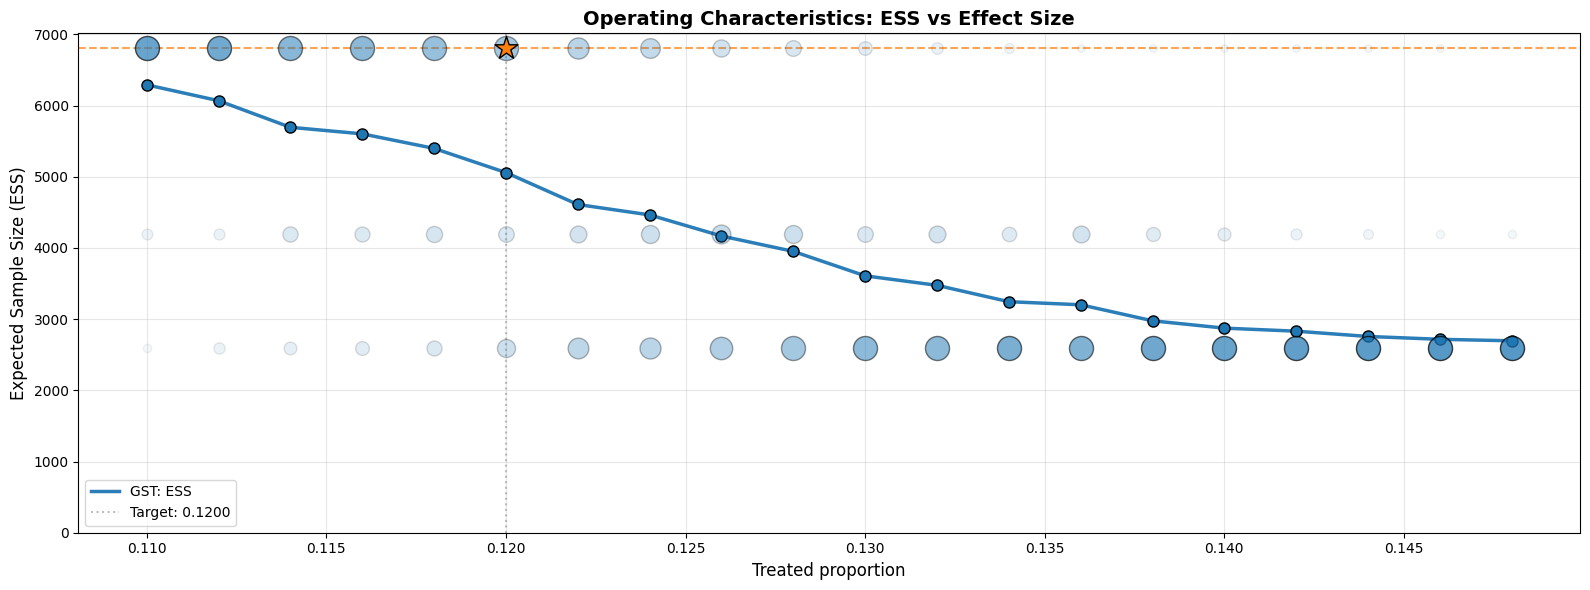

In [5]:
results = {}
for k in ks:
    # Pass plot_options so the plot enforces the requested bottom (e.g. 0)
    results[k] = inst.compare_interim(
        k=k, keep_power_at_H1=True, plot_options={"y_bottom": 0}
    )

# Summarize results
for k, meta in results.items():
    print(f"=== k={k} analyses ===")
    if isinstance(meta, dict):
        print("Keys available:", sorted(list(meta.keys())))
        print("power_at_delta:", meta.get("power_at_delta"))
    else:
        print("Result for k=", k, " ->", repr(meta))

Running comparisons with n_sim = 100
FSD planned_max_n (inst.planned_max_n): 7678

--- k=2 ---
FSD-fixed: planned_max_n= 7678 , power_at_delta= 0.86
Keep-power: planned_max_n= 6402 , power_at_delta= 0.8
  n_per_analysis (fixed) = 1920
  n_per_analysis (keep)  = 1600
  fixed sample_sizes: [3750, 7678] n_fsd_per_group: 3839
  keep sample_sizes: [3127, 6402] n_fsd_per_group: 3839

--- k=3 ---
FSD-fixed: planned_max_n= 7678 , power_at_delta= 0.88
Keep-power: planned_max_n= 6402 , power_at_delta= 0.82
  n_per_analysis (fixed) = 1280
  n_per_analysis (keep)  = 1067
  fixed sample_sizes: [2817, 4721, 7678] n_fsd_per_group: 3839
  keep sample_sizes: [2349, 3937, 6402] n_fsd_per_group: 3839

--- k=2 ---
FSD-fixed: planned_max_n= 7678 , power_at_delta= 0.86
Keep-power: planned_max_n= 6402 , power_at_delta= 0.8
  n_per_analysis (fixed) = 1920
  n_per_analysis (keep)  = 1600
  fixed sample_sizes: [3750, 7678] n_fsd_per_group: 3839
  keep sample_sizes: [3127, 6402] n_fsd_per_group: 3839

--- k=3 --

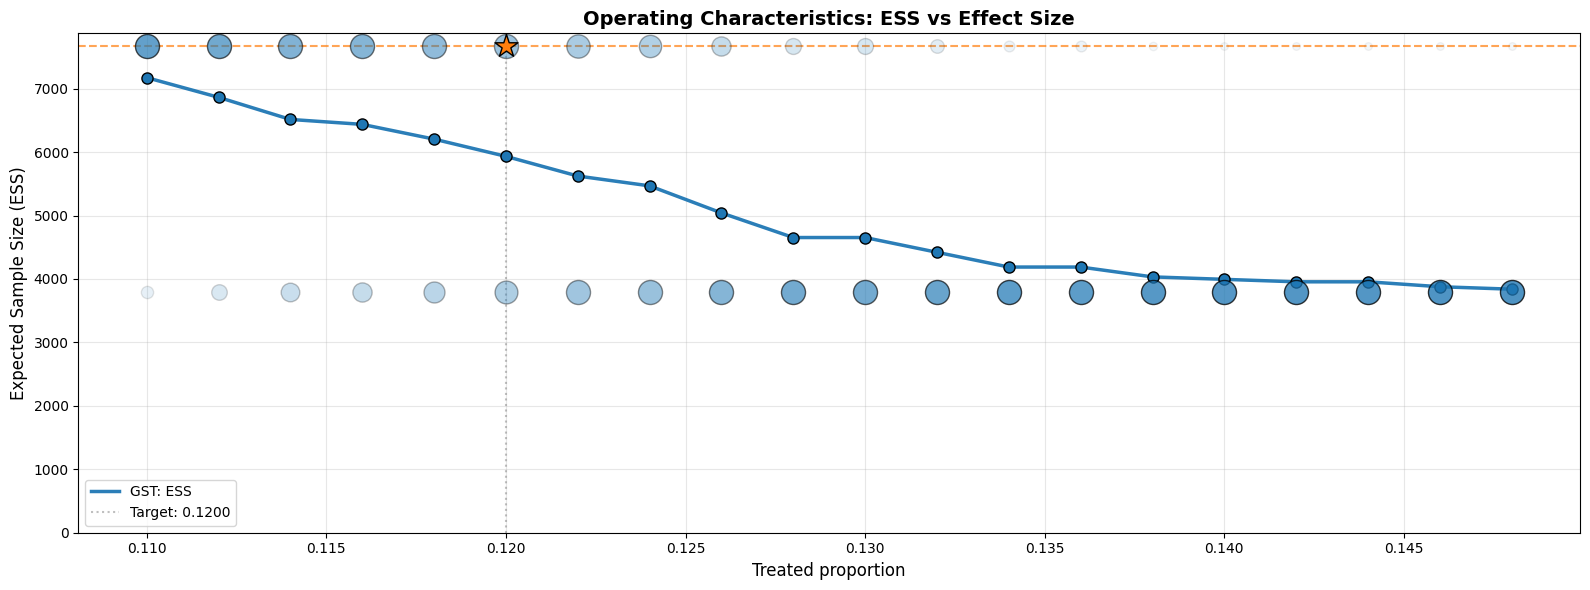

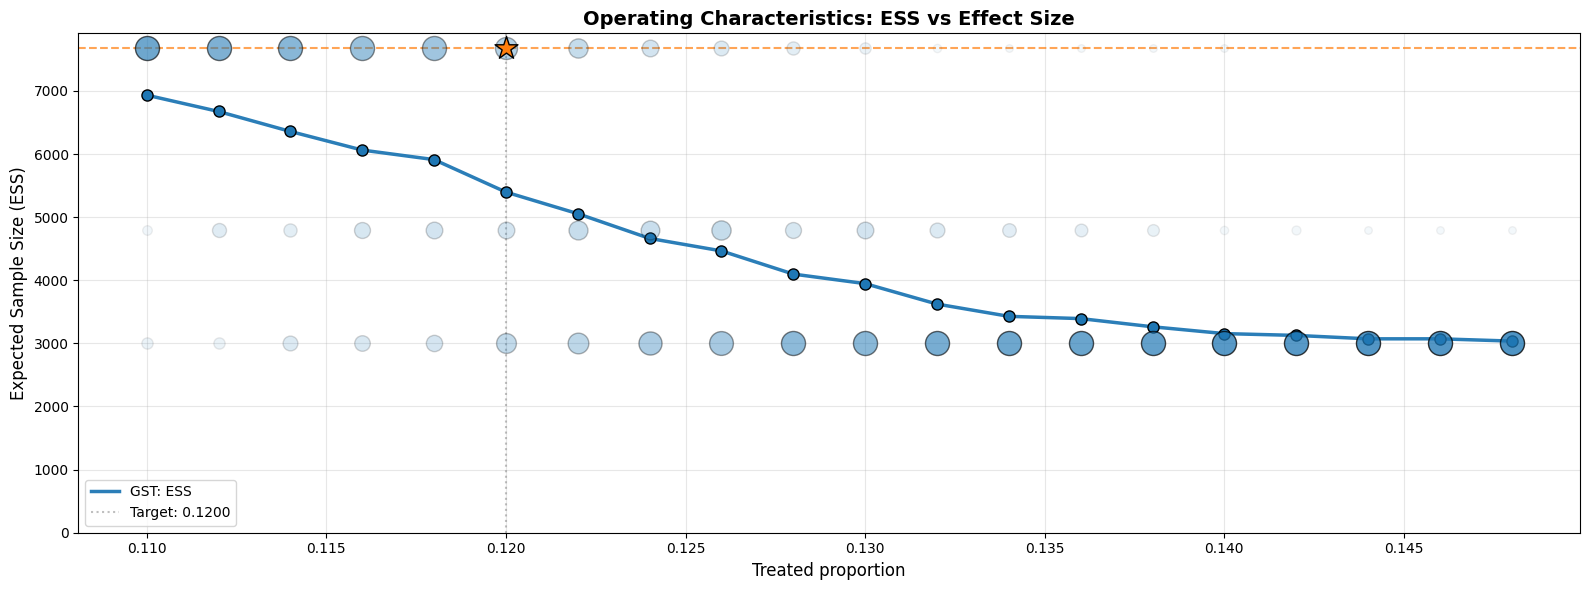

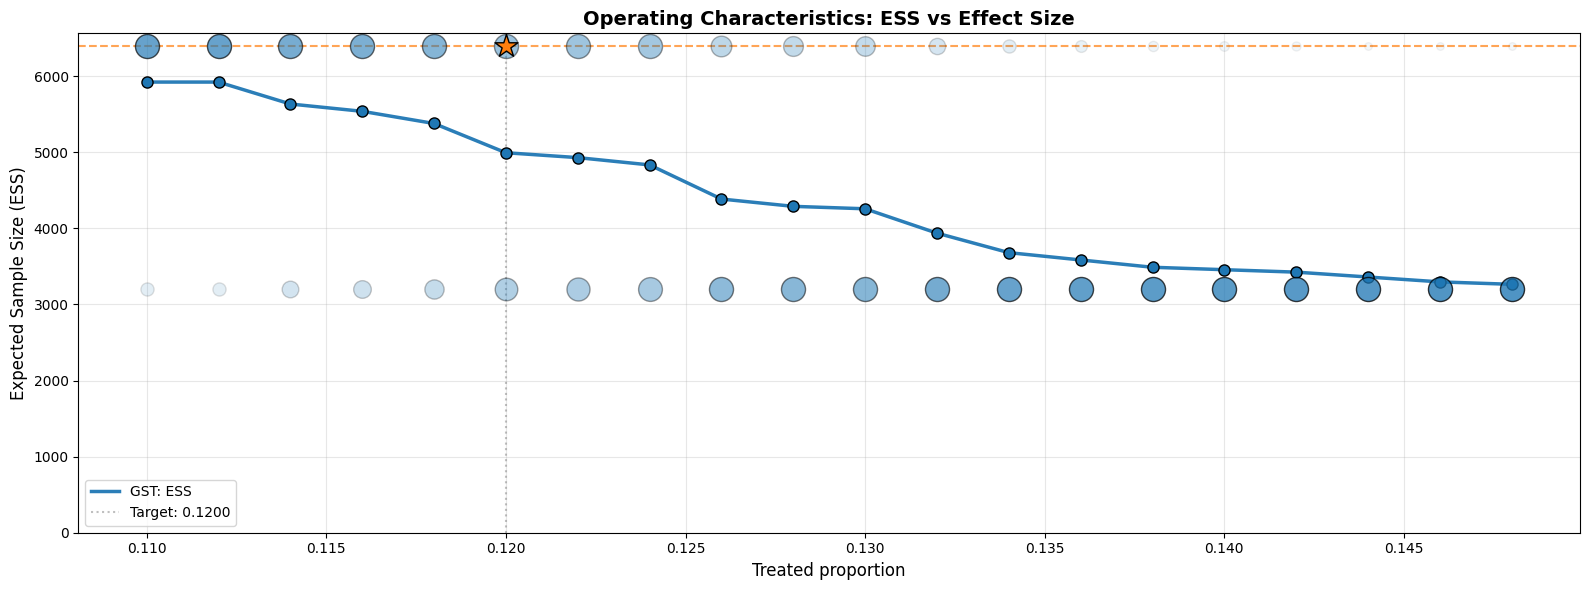

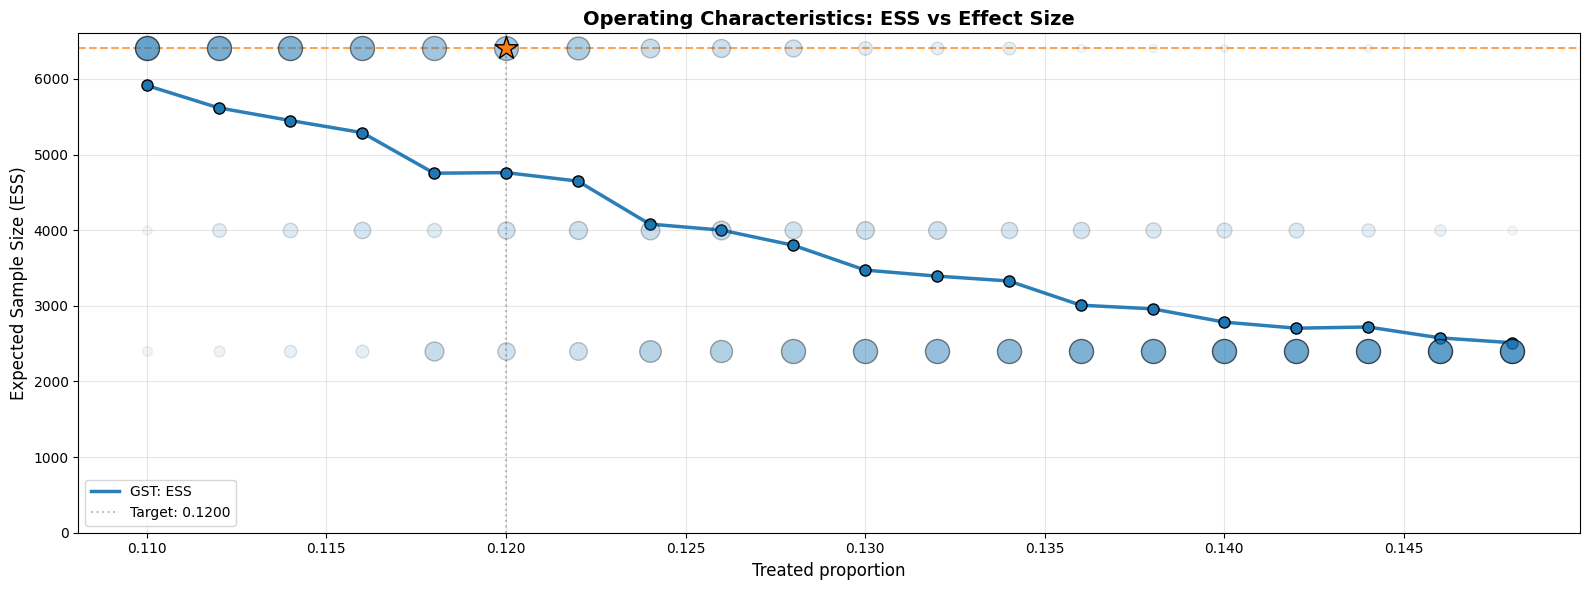

In [6]:
# Diagnostic cell: increase n_sim and compare FSD-fixed vs keep_power_at_H1
# Compare add_interim (fixed FSD budget) against add_interim_keep_power using more simulations.

n_sim_large = 100
print(f"Running comparisons with n_sim = {n_sim_large}")

print("FSD planned_max_n (inst.planned_max_n):", getattr(inst, "planned_max_n", None))

res_fixed = add_interim(
    alpha=alpha,
    delta=delta,
    power=power,
    ks=ks,
    spending=spending,
    p_control=p_control,
    effect_sizes=inst.effect_sizes,
    n_sim=n_sim_large,
    batch_size=batch_size,
    allocation_ratio=allocation_ratio,
    seed=seed,
    plot_options={"y_bottom": 0},
)

res_keep = add_interim_keep_power(
    alpha=alpha,
    delta=delta,
    power=power,
    ks=ks,
    spending=spending,
    p_control=p_control,
    effect_sizes=inst.effect_sizes,
    n_sim=n_sim_large,
    batch_size=batch_size,
    allocation_ratio=allocation_ratio,
    seed=seed,
    tol=0.0,
    plot_options={"y_bottom": 0},
)

for k in ks:
    rf = res_fixed[int(k)]
    rk = res_keep[int(k)]
    print(f"\n--- k={k} ---")
    print(
        "FSD-fixed: planned_max_n=",
        rf.get("planned_max_n"),
        ", power_at_delta=",
        rf.get("power_at_delta"),
    )
    print(
        "Keep-power: planned_max_n=",
        rk.get("planned_max_n"),
        ", power_at_delta=",
        rk.get("power_at_delta"),
    )
    print("  n_per_analysis (fixed) =", rf.get("n_per_analysis"))
    print("  n_per_analysis (keep)  =", rk.get("n_per_analysis"))

    for label, meta in (("fixed", rf), ("keep", rk)):
        oc = meta.get("oc_results", [])
        if not oc:
            continue
        closest = min(oc, key=lambda r: abs(r.effect_size - float(delta)))
        md = getattr(closest, "metadata", {}) or {}
        print(
            f"  {label} sample_sizes:",
            md.get("sample_sizes"),
            "n_fsd_per_group:",
            md.get("n_fsd_per_group"),
        )

In [7]:
# Cell: Estimate FSD power by simulation
# Evaluate the fixed-sample design (FSD) power using the planned_max_n from inst.design_fst().

from earlysign.stats.essentials.schemes.two_proportions.simulator import (
    TwoProportionsSimulator,
)

n_sim_fsd = 2000

if "procedure_factory" not in globals():
    raise RuntimeError(
        "procedure_factory is undefined; run the earlier setup cell before this one."
    )

fsd_total_raw = getattr(inst, "planned_max_n", None)
if fsd_total_raw is None:
    raise RuntimeError("inst.planned_max_n is not set; call inst.design_fst() first")

fsd_total = int(fsd_total_raw)
info_times = [1.0]

procedure = procedure_factory(info_times, fsd_total, None, seed)
fsd_metadata = procedure.snapshot_metadata()
per_group_total = max(1, fsd_total // 2)

sim = TwoProportionsSimulator(
    effect_size=delta,
    n_simulations=int(n_sim_fsd),
    batch_size=int(batch_size),
    allocation_ratio=float(allocation_ratio),
)

point = sim.simulate(
    procedure,
    p_control=float(p_control),
    effect_size=float(delta),
    n_simulations=int(n_sim_fsd),
    rng_seed=seed,
    max_total=fsd_total,
)

print("FSD planned_max_n:", fsd_total)
print("per_group_total:", per_group_total)
print(
    f"Estimated FSD power at delta={delta} (n_sim={n_sim_fsd}):",
    float(point.power),
)

md = getattr(point, "metadata", {}) or {}
if not md.get("sample_sizes"):
    md.setdefault("sample_sizes", fsd_metadata.get("sample_sizes"))
print("sample_sizes (from metadata):", md.get("sample_sizes"))

FSD planned_max_n: 7678
per_group_total: 3839
Estimated FSD power at delta=0.02 (n_sim=2000): 0.81
sample_sizes (from metadata): [7678]


In [8]:
# Demo: form DesignPayloadModel payload from comparison result and call BinomialABTest.set_design()
# The ledger now normalises payloads, so we only need to build a plain-Python dict.

k_choice = 3
variant = "keep"  # "fixed" or "keep"

if variant == "keep":
    meta = res_keep[int(k_choice)]
else:
    meta = res_fixed[int(k_choice)]

planned_max_n = int(meta.get("planned_max_n"))
info_times = list(map(float, meta.get("info_times", [])))

# Build a minimal DesignPayload compatible dict — keep metadata intentionally small
design_payload = {
    "alpha": float(alpha),
    "hypothesis": {"structure": "two_sided_symmetric"},
    "statistic": {"kind": "wald_z", "scale": "z"},
    "efficacy": {
        "style": "alpha_spending",
        "family": str(_spending_family(spending_obj)),
    },
    "futility": {"mode": "none", "binding_mode": "non_binding"},
    "planned_max_n": int(planned_max_n),
    "planned_info_times": info_times,
    # Minimal metadata only — no boundaries preview or oc_results
    "metadata": {
        "generated_from": "fst_to_gst.compare_interim",
        "k": int(k_choice),
    },
}

print("Design payload (summary):")
print(" planned_max_n:", design_payload["planned_max_n"])
print(" planned_info_times:", design_payload["planned_info_times"])
print(" efficacy.family:", design_payload["efficacy"]["family"])

# Create an in-memory BinomialABTest and set design
conn = ibis.connect("duckdb://:memory:")
test = BinomialABTest(conn, "demo_experiment_design_demo")
print("Calling test.set_design(...) with the assembled payload...")
test.set_design(design_payload)

# Confirm saved payload
from earlysign.stats.applications.execution.methods.group_sequential.records.design import (
    GroupSequentialDesignRecord,
)

design_record = GroupSequentialDesignRecord("design").attach(test.ledger)
df = design_record.latest().select(payload=design_record.t.payload).execute()
if len(df) > 0:
    payload = df.iloc[0]["payload"]
    print("Design saved — keys:", list(payload.keys()))
    print("planned_max_n:", payload.get("planned_max_n"))
    print("planned_info_times:", payload.get("planned_info_times"))
else:
    raise RuntimeError("No design found after set_design(); investigation required")

Design payload (summary):
 planned_max_n: 6402
 planned_info_times: [0.3669100238, 0.6149194787, 1.0]
 efficacy.family: pocock
Calling test.set_design(...) with the assembled payload...
Design saved — keys: ['alpha', 'efficacy', 'futility', 'hypothesis', 'metadata', 'planned_info_times', 'planned_max_n', 'statistic']
planned_max_n: 6402
planned_info_times: [0.3669100238, 0.6149194787, 1.0]


In [9]:
test.ledger.show().iloc[0]["payload"]

{'alpha': 0.05,
 'efficacy': {'alpha_levels': None,
  'family': 'pocock',
  'fixed_thresholds': None,
  'gamma': None,
  'style': 'alpha_spending'},
 'futility': {'beta': None,
  'binding_mode': 'non_binding',
  'family': None,
  'gamma': None,
  'mode': 'none',
  'z': None},
 'hypothesis': {'description': None,
  'structure': 'two_sided_symmetric',
  'tail': None},
 'metadata': {'generated_from': 'fst_to_gst.compare_interim', 'k': 3},
 'planned_info_times': [0.3669100238, 0.6149194787, 1.0],
 'planned_max_n': 6402,
 'statistic': {'kind': 'wald_z', 'metadata': None, 'scale': 'z'}}

Minimal `BinomialABTest` example

Here we create a ledger-backed `BinomialABTest` instance. This demonstrates the ledger wiring; we avoid running a full sequential update in this demo to keep the cell fast and side-effect free.

In [10]:
# Create an in-memory DuckDB-backed BinomialABTest (no operations performed)
conn = ibis.connect("duckdb://:memory:")
test = BinomialABTest(conn, "demo_experiment")
print("Created BinomialABTest with experiment_id =", test.experiment_id)

# You can inspect the ledger or call test.plot_design() after setting a design.
print("Ledger attached (type):", type(test.ledger))

Created BinomialABTest with experiment_id = demo_experiment
Ledger attached (type): <class 'earlysign.core.ledger.Ledger'>


## Example: using AddInterimToFixedSampleTest with BinomialABTest

This short example shows how to (a) create or reuse an `AddInterimToFixedSampleTest` helper, (b) derive a compact GST design for a chosen `k`, and (c) persist a minimal design payload into a `BinomialABTest` ledger using `set_design()`.

The demo keeps the payload minimal (no large previews) and uses small `n_sim` values in the function call so it runs quickly in interactive environments.


Creating AddInterimToFixedSampleTest (n_sim=100) and running design_fst()...
Running compare_interim(k=3, keep_power_at_H1=True) on the class instance...
Calling test.set_design(...) with minimal payload from class-based flow...
Design saved — keys: ['alpha', 'efficacy', 'futility', 'hypothesis', 'metadata', 'planned_info_times', 'planned_max_n', 'statistic']
planned_max_n: 6397
planned_info_times: [0.3669100238, 0.6149194787, 1.0]
Calling test.set_design(...) with minimal payload from class-based flow...
Design saved — keys: ['alpha', 'efficacy', 'futility', 'hypothesis', 'metadata', 'planned_info_times', 'planned_max_n', 'statistic']
planned_max_n: 6397
planned_info_times: [0.3669100238, 0.6149194787, 1.0]


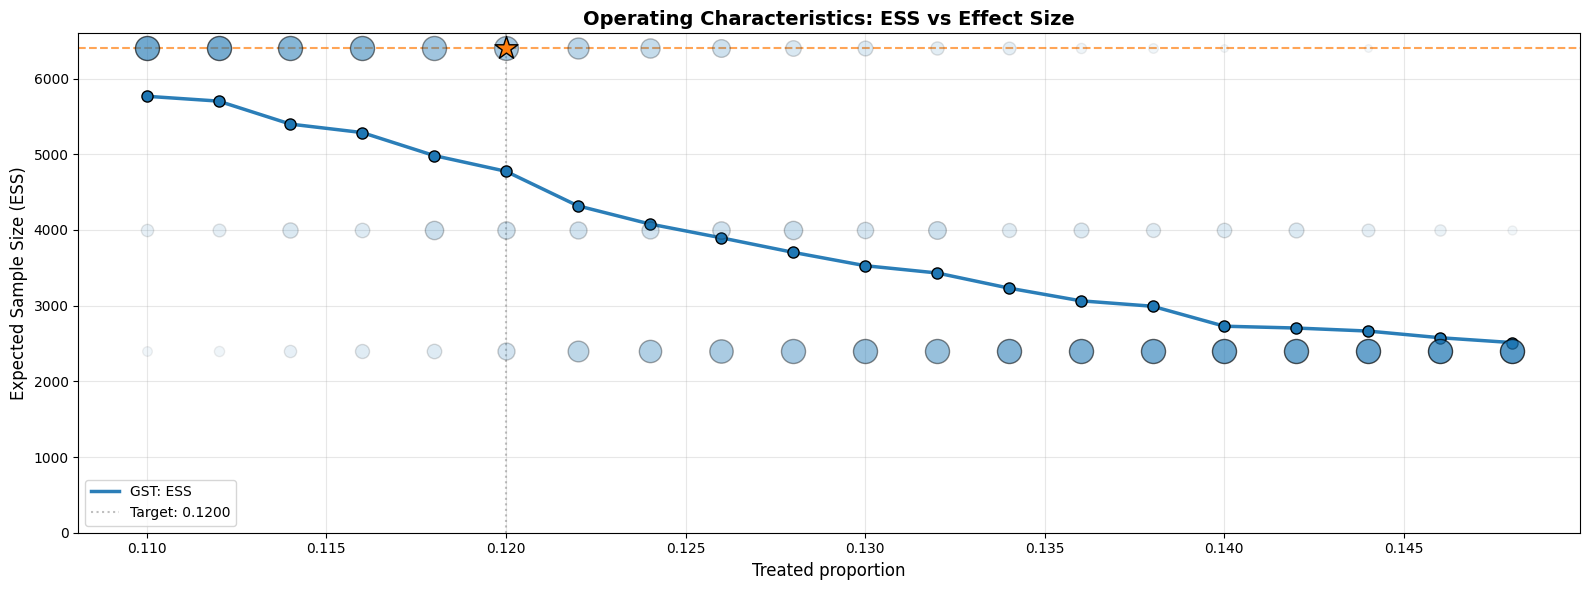

In [11]:
# Demo: derive a minimal GST design using AddInterimToFixedSampleTest (class) and persist via BinomialABTest
# Instantiate AddInterimToFixedSampleTest, run design_fst(), collect compare_interim metadata,
# and store the resulting design in an in-memory ledger.

from earlysign.stats.applications.design.group_sequential.initial_design.scenarios.fst_to_gst import (
    AddInterimToFixedSampleTest,
)

k_choice = 3
n_sim_demo = 100  # small for interactive demo; increase for precision

print(
    f"Creating AddInterimToFixedSampleTest (n_sim={n_sim_demo}) and running design_fst()..."
)
demo_inst = AddInterimToFixedSampleTest(
    alpha=alpha,
    delta=delta,
    power=power,
    p_control=p_control,
    allocation_ratio=allocation_ratio,
    procedure_factory=procedure_factory,
    asn_calculator_factory=asn_calculator_factory,
    effect_sizes=np.arange(0.01, 0.05, 0.002).tolist(),
    n_sim=n_sim_demo,
    batch_size=batch_size,
    seed=seed,
)

demo_inst.design_fst()

print(
    f"Running compare_interim(k={k_choice}, keep_power_at_H1=True) on the class instance..."
)
meta = demo_inst.compare_interim(
    k=k_choice, keep_power_at_H1=True, plot_options={"y_bottom": 0}
)

if not isinstance(meta, dict):
    raise RuntimeError(
        "compare_interim did not return metadata dict; check earlier steps"
    )

planned_max_n = int(meta.get("planned_max_n"))
planned_info_times = list(map(float, meta.get("info_times", [])))

# Minimal JSON-serializable payload (no heavy previews)
design_payload = {
    "alpha": float(alpha),
    "hypothesis": {"structure": "two_sided_symmetric"},
    "statistic": {"kind": "wald_z", "scale": "z"},
    "efficacy": {
        "style": "alpha_spending",
        "family": str(_spending_family(spending_obj)),
    },
    "futility": {"mode": "none", "binding_mode": "non_binding"},
    "planned_max_n": int(planned_max_n),
    "planned_info_times": planned_info_times,
    "metadata": {
        "generated_from": "AddInterimToFixedSampleTest.compare_interim",
        "k": int(k_choice),
    },
}

# Persist into an in-memory BinomialABTest ledger
conn = ibis.connect("duckdb://:memory:")
test = BinomialABTest(conn, f"demo_class_design_k{k_choice}")
print("Calling test.set_design(...) with minimal payload from class-based flow...")
test.set_design(design_payload)

# Confirm saved payload
from earlysign.stats.applications.execution.methods.group_sequential.records.design import (
    GroupSequentialDesignRecord,
)

design_record = GroupSequentialDesignRecord("design").attach(test.ledger)
df = design_record.latest().select(payload=design_record.t.payload).execute()
if len(df) == 0:
    raise RuntimeError("No design found after set_design(); investigation required")

payload = df.iloc[0]["payload"]
print("Design saved — keys:", list(payload.keys()))
print("planned_max_n:", payload.get("planned_max_n"))
print("planned_info_times:", payload.get("planned_info_times"))

design_fst: n_fsd_per_group=3839 planned_max_n=7678

=== Template compare_interim() label=fixed_budget keep_power_at_H1=False ===
[run=1 k=2 keep_power=False] _optimize_info_times: k=2 info_times=[0.4884, 1.0]
[run=1 k=2 keep_power=False] compare_interim: k=2 keep_power_at_H1=False
[run=1 k=2 keep_power=False] compare_interim: using planned_max_n=7678 (FSD total)
[run=1 k=2 keep_power=False] compare_interim: evaluating 1 effect sizes
[run=1 k=2 keep_power=False] compare_interim: effect_size[1/1]=0.02
[run=1 k=2 keep_power=False] _optimize_info_times: k=2 info_times=[0.4884, 1.0]
[run=1 k=2 keep_power=False] compare_interim: k=2 keep_power_at_H1=False
[run=1 k=2 keep_power=False] compare_interim: using planned_max_n=7678 (FSD total)
[run=1 k=2 keep_power=False] compare_interim: evaluating 1 effect sizes
[run=1 k=2 keep_power=False] compare_interim: effect_size[1/1]=0.02
[run=1 k=2 keep_power=False] compare_interim: completed k=2 planned_max_n=7678 power_at_delta=0.8000
[run=2 k=3 keep_p

KeyboardInterrupt: 

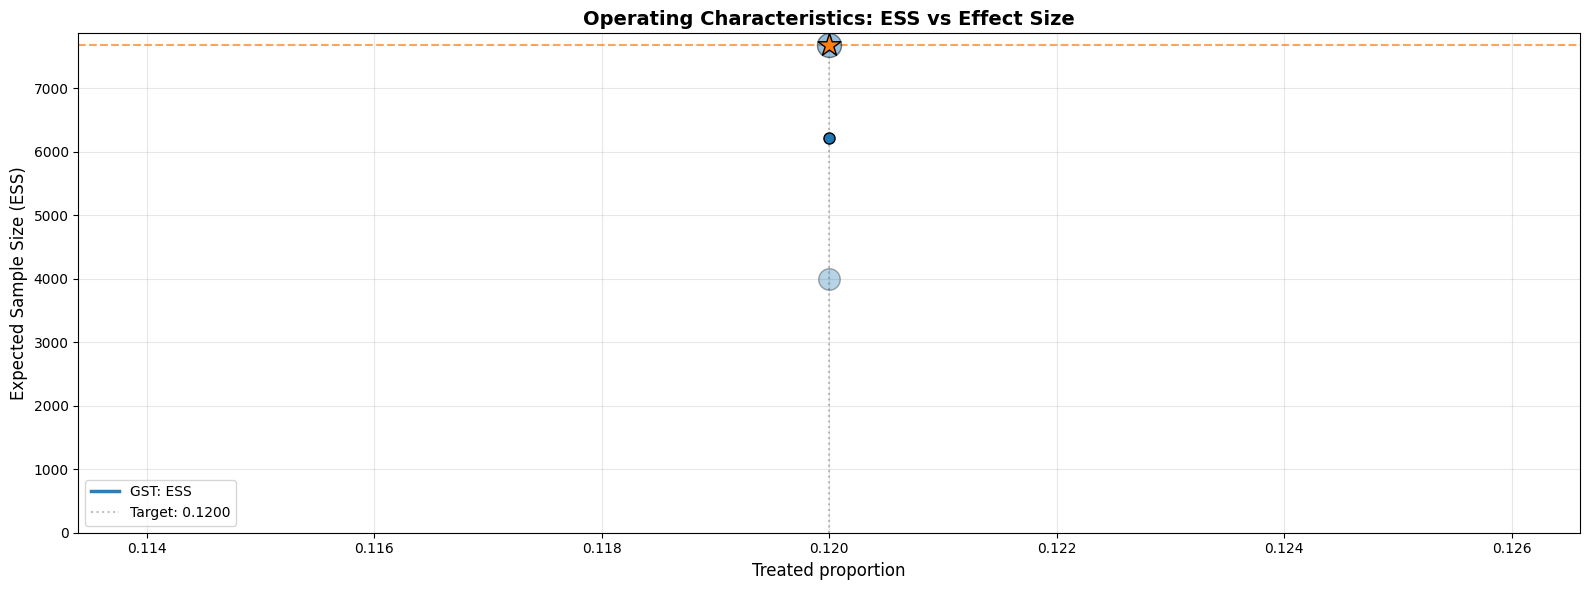

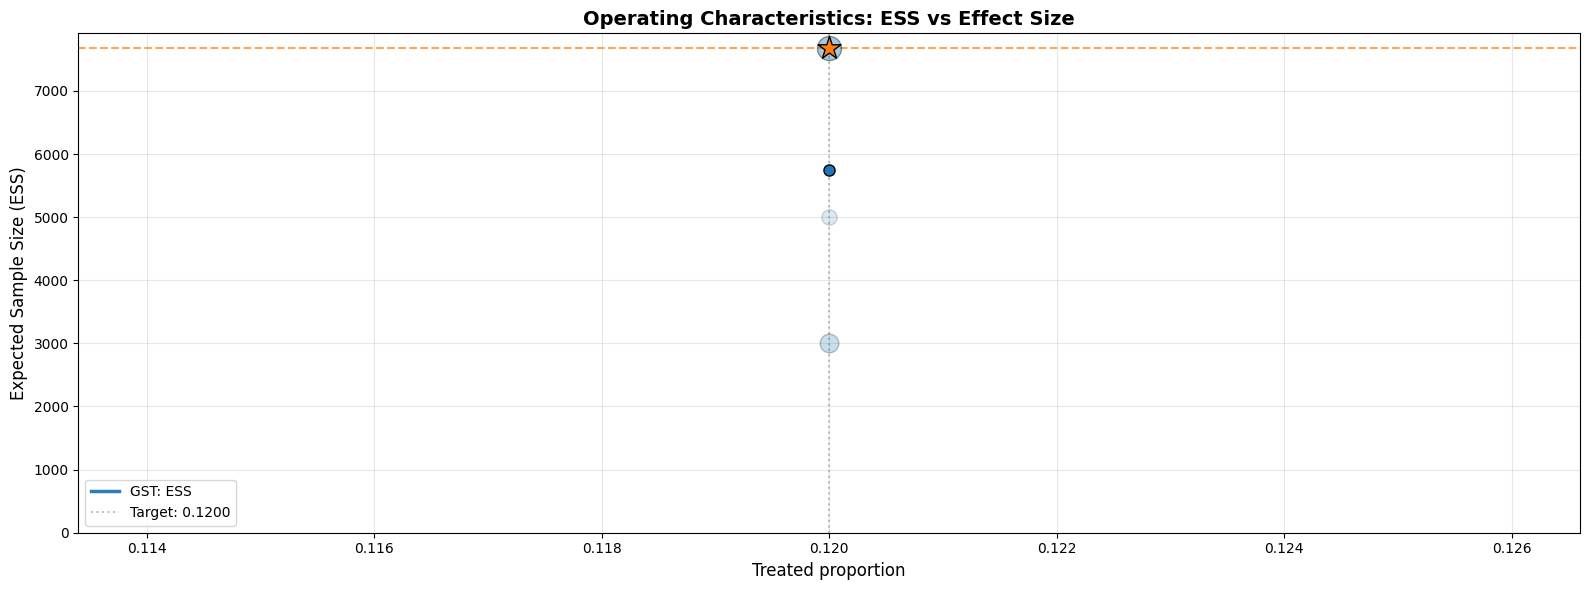

In [12]:
# Demo: run the design through BinomialABTest via build_template_procedure_factory
# This reuses the template helper to expose BinomialABTest as a ProcedureFactory
# so we can call AddInterimToFixedSampleTest.compare_interim() against the ledger-backed flow.

import math
from earlysign.stats.applications.design.group_sequential.initial_design.helpers.template_helpers import (
    build_template_procedure_factory,
)
from earlysign.stats.essentials.schemes.two_proportions.simulator import (
    TwoProportionsSimulator,
)


# Template factory that the helper will call with an ibis backend
def _template_factory(backend, experiment_id, table_name):
    return BinomialABTest(backend, experiment_id)


def _terminate_fn(template, look):
    status = template.status()
    if getattr(status, "stop_recommended", False):
        return {"reject": True, "reason": "template_stop"}
    return None


def _template_payload_builder(info_times, planned_max_n):
    return {
        "alpha": float(alpha),
        "hypothesis": {"structure": "two_sided_symmetric"},
        "statistic": {"kind": "wald_z", "scale": "z"},
        "efficacy": {
            "style": "alpha_spending",
            "family": str(_spending_family(spending_obj)),
        },
        "futility": {"mode": "none", "binding_mode": "non_binding"},
        "planned_max_n": int(planned_max_n),
        "planned_info_times": list(map(float, info_times)),
        "metadata": {
            "generated_from": "template_compare_interim",
            "experiment_id": "sim_template_exp",
        },
    }


template_proc_factory = build_template_procedure_factory(
    template_factory=_template_factory,
    terminate_fn=_terminate_fn,
    experiment_id="sim_template_exp",
    table_name=None,
)

# Keep the template evaluation lightweight so the notebook stays quick in CI
_template_n_sim = 20
_template_batch_size = max(500, batch_size)
_template_effect_sizes = [float(delta)]

template_inst = AddInterimToFixedSampleTest(
    alpha=alpha,
    delta=delta,
    power=power,
    p_control=p_control,
    allocation_ratio=allocation_ratio,
    procedure_factory=template_proc_factory,
    asn_calculator_factory=asn_calculator_factory,
    effect_sizes=_template_effect_sizes,
    n_sim=_template_n_sim,
    batch_size=_template_batch_size,
    seed=seed,
    design_payload_builder=_template_payload_builder,
    verbose=True,
)

template_inst.design_fst()

template_results = {"fixed_budget": {}, "keep_power": {}}
for keep_flag, label in ((False, "fixed_budget"), (True, "keep_power")):
    print(
        f"\n=== Template compare_interim() label={label} keep_power_at_H1={keep_flag} ==="
    )
    for k in ks:
        meta = template_inst.compare_interim(
            k=k, keep_power_at_H1=keep_flag, plot_options={"y_bottom": 0}
        )
        template_results[label][k] = meta
        # if isinstance(meta, dict):
        #     print(
        #         f" {label} k={k}: planned_max_n={meta.get('planned_max_n')}, "
        #         f"power_at_delta={meta.get('power_at_delta')}"
        #     )
        # else:
        #     print(f" {label} k={k}: non-dict result -> {repr(meta)}")

# Optional: run a single simulation using the adapter procedure to confirm wiring
k_template = ks[-1]
meta_keep = template_results["keep_power"].get(k_template)
if not isinstance(meta_keep, dict):
    raise RuntimeError(
        "compare_interim did not return metadata dict for keep_power flow"
    )

_template_info_times = meta_keep.get("info_times", [])
_template_planned_n = int(meta_keep.get("planned_max_n", 0))

if not _template_info_times or not _template_planned_n:
    raise RuntimeError("compare_interim returned empty info_times or planned_max_n")

_adapter_payload = _template_payload_builder(_template_info_times, _template_planned_n)
_template_procedure = template_proc_factory(
    _template_info_times, _template_planned_n, _adapter_payload, seed
)

# Use a coarse batch so the adapter does not issue thousands of ledger updates per run
_dynamic_batch = max(
    10,
    min(
        int(math.ceil(_template_planned_n / max(1, len(_template_info_times)))),
        int(_template_planned_n),
    ),
)
_sim = TwoProportionsSimulator(
    effect_size=delta,
    n_simulations=1,
    batch_size=_dynamic_batch,
    allocation_ratio=allocation_ratio,
)

_batch_unit = _dynamic_batch + int(round(_dynamic_batch * allocation_ratio))
if _batch_unit <= 0:
    _batch_unit = _dynamic_batch
_expected_calls = math.ceil(_template_planned_n / max(1, _batch_unit))
print(
    "\nAdapter simulate: batch_size=",
    _dynamic_batch,
    "expected template.update() calls ≈",
    _expected_calls,
)

print("Running simulator via TemplateProcedureAdapter...")
_template_point = _sim.simulate(
    _template_procedure,
    p_control=float(p_control),
    effect_size=float(delta),
    n_simulations=1,
    rng_seed=seed,
    max_total=_template_planned_n,
)

print("Adapter simulation power:", float(_template_point.power))
print(
    "Adapter metadata sample keys:",
    list((getattr(_template_point, "metadata", {}) or {}).keys()),
)

ledger = getattr(getattr(_template_procedure, "template", None), "ledger", None)
if ledger is not None:
    print()
    print("Adapter template ledger snapshot (head):")
    print(ledger.show().head())
else:
    print("Template procedure did not expose a ledger instance.")

Next steps / pointers:
- Use `add_interim_keep_power` to search for a minimal budget that preserves a target power.
- Integrate the returned design payload into `BinomialABTest.set_design(...)` if you want to run ledger-backed simulations and updates.
- For CI and fast experimentation, keep `n_sim` small (e.g. 100-500) and increase for final runs.